In [2]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250713-naturalness-param-scan',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'HEM3_HUMAN_Loggerenberg_2023', 'HSP82_YEAST_Flynn_2019', 'SHOC2_HUMAN_Kwon_2022', 'BLAT_ECOLX_Firnberg_2014', 'PPM1D_HUMAN_Miller_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'CBS_HUMAN_Sun_2020', 'ANCSZ_Hobbs_2022', 'OXDA_RHOTO_Vanella_2023_activity'}


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_23593/728580424.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


Text(0, 0.5, 'Recall@10% of Held-Out Mutants')

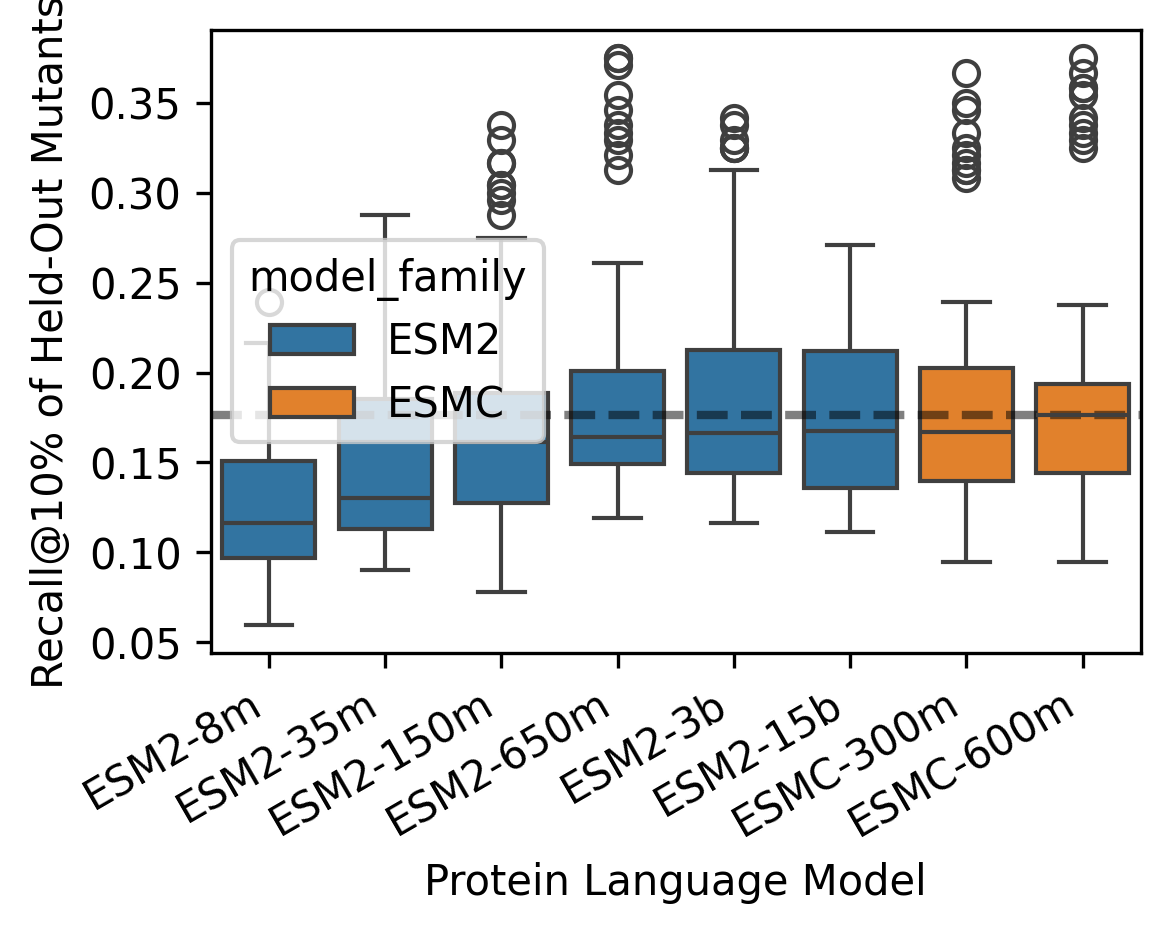

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

METRIC = 'held_out_10pct_recall'

model_name_list = [
    ('FolDE-base', 'base'),
    ('FolDE-8m', 'ESM2-8m'),
    ('FolDE-35m', 'ESM2-35m'),
    ('FolDE-150m', 'ESM2-150m'),
    ('FolDE-650m', 'ESM2-650m'),
    ('FolDE-3b', 'ESM2-3b'),
    ('FolDE-15b', 'ESM2-15b'),
    ('FolDE-300m', 'ESMC-300m'),
    ('FolDE-600m', 'ESMC-600m'),
]
model_name_map = {k: v for k, v in model_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == 1].copy()
initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: model_name_map[x])
initial_metrics_df['model_family'] = initial_metrics_df.model_name.apply(lambda x: x.split('-')[0])

plt.figure(figsize=(4, 2.7), dpi=300)
ax = sns.boxplot(
    data=initial_metrics_df[
        (initial_metrics_df.model_name != 'base')
    ],
    x='model_name',
    y=METRIC,
    order=[v for k, v in model_name_list[1:]],
    hue='model_family',
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

ax.axhline(
    y=initial_metrics_df[initial_metrics_df.model_name == 'ESMC-600m'][METRIC].median(),
    color='black',
    linestyle='--',
    linewidth=2,
    alpha=0.5,
    label='ESMC-600m median'
)

plt.xlabel('Protein Language Model')
plt.ylabel('Recall@10% of Held-Out Mutants')






